# Silver Layer - Data Preprocessing & Analysis

This notebook performs the **Silver Layer** processing of the Medallion Architecture:

## Objectives
1. **Data Merging**: LEFT join BoB + Retention data (keeps all BoB customers)
2. **Churn Classification**: 3-class target (no_churn, partial_churn, full_churn)
3. **Feature Engineering**: Customer-level features from BoB data
4. **Exploratory Data Analysis**: Distributions, correlations, box plots
5. **Hypothesis Testing**: 6 business-driven statistical tests
6. **Save Processed Data**: For Gold layer modeling

## Churn Definition (Use Case)
- `resolution_status == 'Customer Lost'` → churn for that agreement
- When a customer loses ALL linked agreements → **full customer churn**
- When a customer loses SOME but not all → **partial churn**
- No loss at all → **no churn**

---
# 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib.util, sys
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# ── Load custom modules ──
modules_to_load = {
    'merge_data': '../../src/data/merge_data.py',
    'churn_classification': '../../src/features/churn_classification.py',
    'feature_engineering': '../../src/features/feature_engineering.py',
    'hypothesis_testing': '../../src/features/hypothesis_testing.py',
}
mods = {}
for name, path in modules_to_load.items():
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    mods[name] = mod

print('All modules loaded.')

All modules loaded.


---
# 2. Load Cleaned Data (from Bronze Layer)

In [2]:
bob_df = pd.read_csv('../../data/02_intermediate/cleaned_bob.csv')
ret_df = pd.read_csv('../../data/02_intermediate/cleaned_retention.csv')

print(f'BoB data:       {bob_df.shape[0]:>8,} rows × {bob_df.shape[1]} cols')
print(f'Retention data: {ret_df.shape[0]:>8,} rows × {ret_df.shape[1]} cols')
print(f'\nUnique customers in BoB:       {bob_df["account_number"].nunique():,}')
print(f'Unique customers in Retention: {ret_df["customer_account_number"].nunique():,}')

BoB data:        171,665 rows × 14 cols
Retention data:   35,286 rows × 4 cols

Unique customers in BoB:       23,772
Unique customers in Retention: 21,526


In [3]:
print('--- BoB Sample ---')
display(bob_df.head())
print('\n--- Retention Sample ---')
display(ret_df.head())

--- BoB Sample ---


,account_number,branch,agreement_number,agreement_start_date,agreement_end_date,agreement_type,system_status,product_bob,fee_bob,total_bob,is_bob,unit_amount,msdyn_product_number,product_name
0,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,Yes,9812.14,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...
1,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...
2,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...
3,UK02-CGBA124601-L,Lisburn,GBC4000950-Auto waste,2022-06-24,2026-06-23,Scheduled Billing,Active,92242.56,0.0,92242.56,Yes,7686.88,K0000-040259-000,Waste Paint Sludge Collection - 205
4,UK02-CGBA034502-L,Lisburn,GBC3028394-Chemistry,2024-11-04,2025-11-03,Scheduled Billing,Active,83206.92,0.0,83206.92,Yes,6933.91,C0000-000468-001,Delivery of Std Thinners - 205Ltrs (6)



--- Retention Sample ---


,customer_account_number,case_type,current_status,resolution_status
0,UK02-CGBA121453-L,Risk,In Progress,OPEN - In Progress
1,UK02-CGBA027133-L,Risk,In Progress,OPEN - In Progress
2,UK02-SGBA028701-L,Risk,In Progress,OPEN - In Progress
3,UK02-CGBA210070-L,Risk,In Progress,OPEN - In Progress
4,UK02-CGBA212953-L,Risk,In Progress,OPEN - In Progress


## 2.1 Quick EDA on Source Data

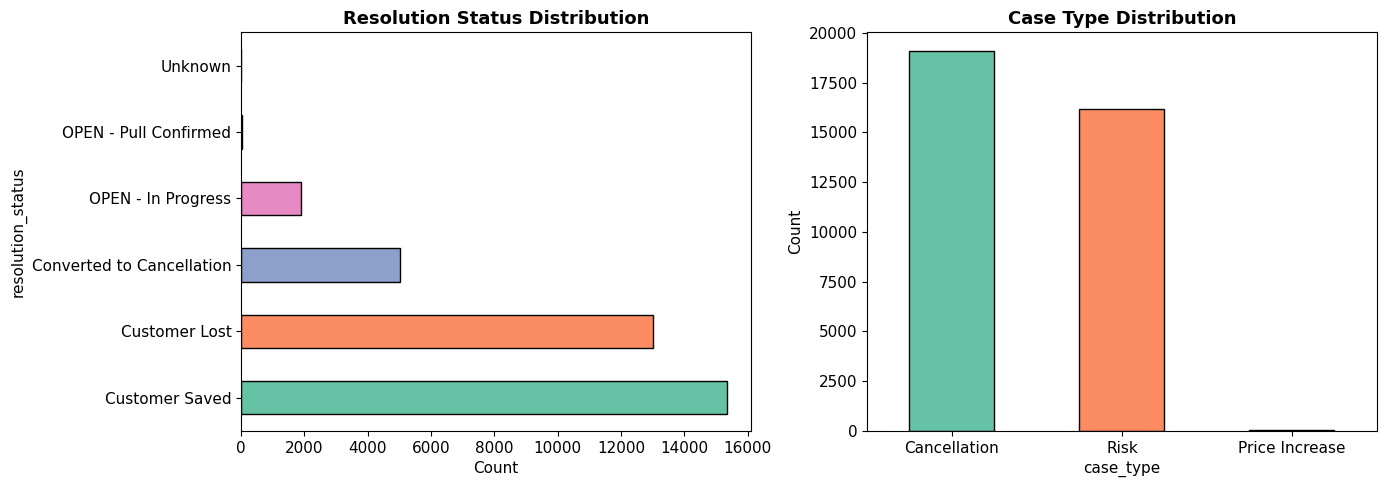

In [4]:
# Retention - Resolution Status distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ret_df['resolution_status'].value_counts().plot(
    kind='barh', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Resolution Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

ret_df['case_type'].value_counts().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('Set2'), edgecolor='black')
axes[1].set_title('Case Type Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

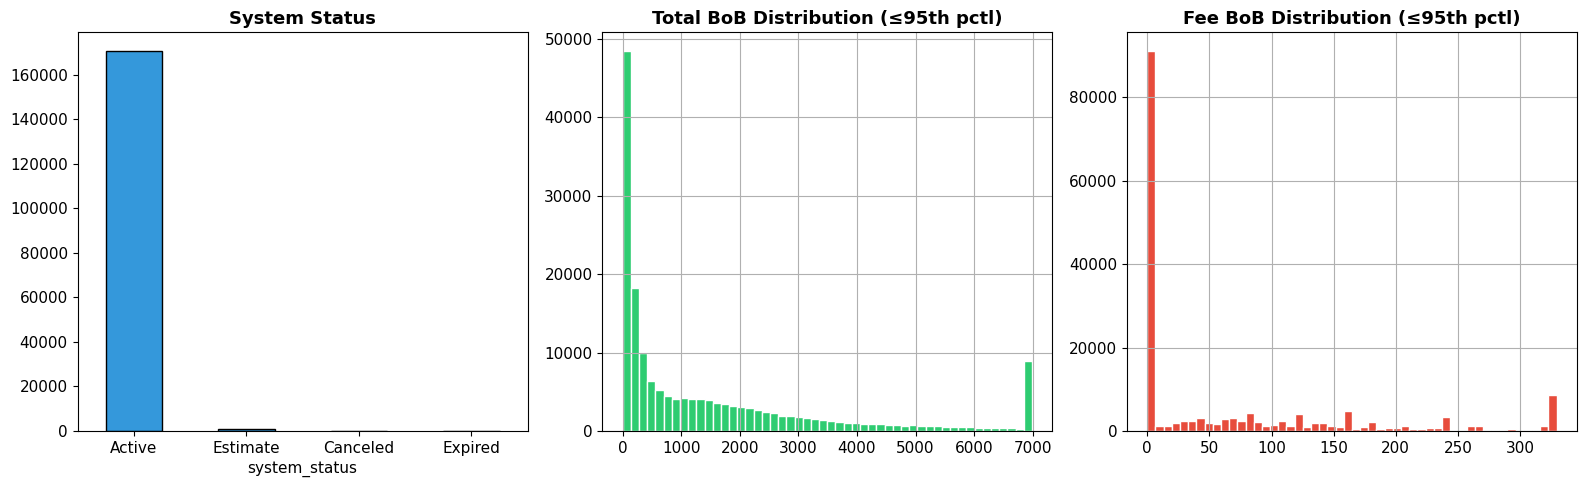

In [5]:
# BoB - System Status and Key Numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bob_df['system_status'].value_counts().plot(
    kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('System Status', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

bob_df['total_bob'].clip(upper=bob_df['total_bob'].quantile(0.95)).hist(
    bins=50, ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Total BoB Distribution (≤95th pctl)', fontsize=13, fontweight='bold')

bob_df['fee_bob'].clip(upper=bob_df['fee_bob'].quantile(0.95)).hist(
    bins=50, ax=axes[2], color='#e74c3c', edgecolor='white')
axes[2].set_title('Fee BoB Distribution (≤95th pctl)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 3. Data Merging (LEFT JOIN)

We use a **LEFT JOIN** from BoB to Retention to ensure **all BoB customers** are included.  
Customers without retention records are natural no-churn candidates.

In [6]:
merger = mods['merge_data'].MergeData(ret_df, bob_df)
merged_df = merger.merge_data()

# Save merged data
merged_df.to_csv('../../data/03_processed/merged_data.csv', index=False)
print('\nMerged data saved to data/03_processed/merged_data.csv')
display(merged_df.head())

Merging retention and BoB data (LEFT JOIN)...
Merged dataset shape: (207275, 17)
Columns: ['account_number', 'branch', 'agreement_number', 'agreement_start_date', 'agreement_end_date', 'agreement_type', 'system_status', 'product_bob', 'fee_bob', 'total_bob', 'is_bob', 'unit_amount', 'msdyn_product_number', 'product_name', 'case_type', 'current_status', 'resolution_status']
Unique customers: 23772

Merged data saved to data/03_processed/merged_data.csv


,account_number,branch,agreement_number,agreement_start_date,agreement_end_date,agreement_type,system_status,product_bob,fee_bob,total_bob,is_bob,unit_amount,msdyn_product_number,product_name,case_type,current_status,resolution_status
0,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,Yes,9812.14,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...,Risk,In Progress,OPEN - In Progress
1,UK02-CGBA029544-L,Elmswell,GBC4019041-Machine Services-327311,2025-03-17,2026-03-16,Scheduled Billing,Active,117745.68,0.0,117745.68,Yes,9812.14,ISK400EAA-001483-001,SK400 EAA + 400L of KLEEN7960S + Waste Rustpro...,Cancellation,In Progress,OPEN - In Progress
2,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,Risk,In Progress,OPEN - In Progress
3,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332280,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,Cancellation,In Progress,OPEN - In Progress
4,UK02-CGBA029544-L,Elmswell,GBC4021962-Machine Services-332282,2025-04-14,2028-04-13,Scheduled Billing,Active,105967.68,0.0,105967.68,Yes,8830.64,ISK600EAA-001356-001,SK600 EAA + 600L of KLEEN7960S + Waste Rustpro...,Risk,In Progress,OPEN - In Progress


---
# 4. Churn Classification (3-Class)

Classification logic per customer:
- **no_churn**: No retention case OR no 'Customer Lost' outcome
- **partial_churn**: SOME retention cases resulted in 'Customer Lost' (not all)
- **full_churn**: ALL retention cases resulted in 'Customer Lost'

In [7]:
classifier = mods['churn_classification'].ChurnClassification(merged_df)
churn_df = classifier.classify_churn()

# Save churn classified data
churn_df.to_csv('../../data/03_processed/churn_categorised.csv', index=False)
print('\nSaved to data/03_processed/churn_categorised.csv')
display(churn_df.head(10))

Performing churn classification...

Churn classification complete.
Total customers: 23772

Churn Distribution:
         no_churn:  22370 (94.1%)
    partial_churn:   1067 (4.5%)
       full_churn:    335 (1.4%)

Saved to data/03_processed/churn_categorised.csv


,account_number,total_retention_cases,customer_lost_cases,customer_saved_cases,num_agreements,churn_category
0,UK02-CGBA029544-L,374,0,0,94,no_churn
1,UK02-CGBA124601-L,14,0,14,3,no_churn
2,UK02-CGBA034502-L,32,8,8,3,partial_churn
3,UK02-CGBA110426-L,2,0,2,1,no_churn
4,UK02-SGBA013690-L,0,0,0,16,no_churn
5,UK02-CGBA029184-L,0,0,0,29,no_churn
6,UK02-SGBA034070-L,0,0,0,8,no_churn
7,UK02-SGBA026468-L,0,0,0,5,no_churn
8,UK02-CGBA203138-L,64,0,48,8,no_churn
9,UK02-CGBA000084-L,291,0,97,48,no_churn


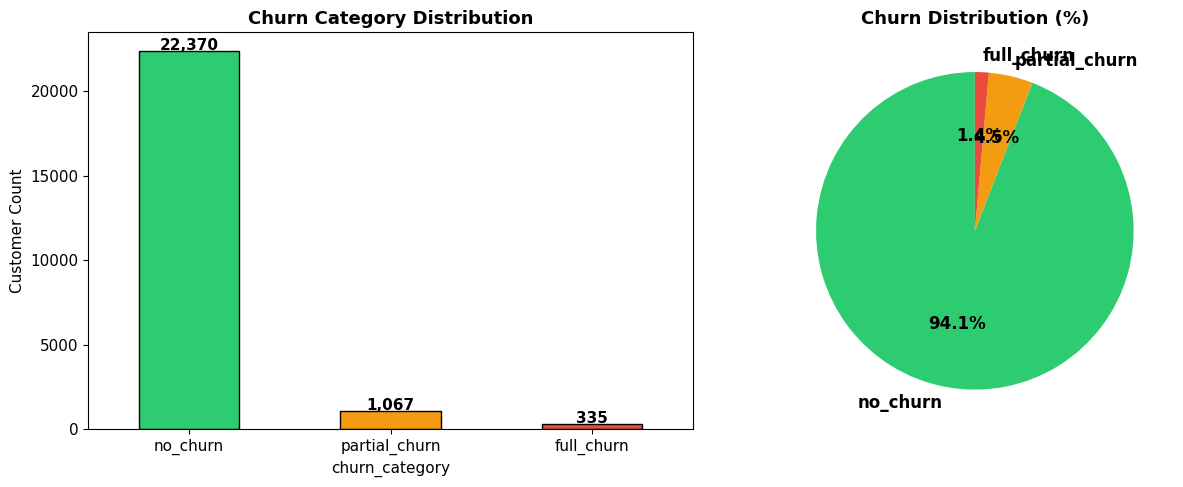

In [8]:
# Visualise churn distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
order = ['no_churn', 'partial_churn', 'full_churn']
dist = churn_df['churn_category'].value_counts().reindex(order)

dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=0)
for i, val in enumerate(dist.values):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(dist.values, labels=order, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 5. Feature Engineering

Aggregate row-level BoB data into **customer-level features**:
- **Financial**: total_revenue, avg_revenue, total_fees, avg_unit_amount
- **Agreement**: num_agreements, num_branches, num_agreement_types, num_products
- **Temporal**: avg_agreement_duration, max_agreement_duration
- **Behavioral**: bob_ratio, num_retention_cases

In [9]:
fe = mods['feature_engineering'].FeatureEngineering(merged_df)
customer_features = fe.engineer_features()

# Merge with churn labels
analysis_df = customer_features.merge(
    churn_df[['account_number', 'churn_category']],
    on='account_number', how='left'
)

print(f'\nAnalysis dataset: {analysis_df.shape}')
display(analysis_df.head())
display(analysis_df.describe().round(2))

Starting customer-level feature engineering...
Feature engineering complete. Customer-level shape: (23772, 19)
Features: ['account_number', 'total_revenue', 'avg_revenue', 'total_product_value', 'total_fees', 'avg_fees', 'avg_unit_amount', 'max_unit_amount', 'num_agreements', 'num_branches', 'num_agreement_types', 'num_products', 'avg_agreement_duration', 'max_agreement_duration', 'bob_ratio', 'num_retention_cases', 'dominant_agreement_type', 'revenue_per_agreement', 'fee_to_revenue_ratio']

Analysis dataset: (23772, 20)


,account_number,total_revenue,avg_revenue,total_product_value,total_fees,avg_fees,avg_unit_amount,max_unit_amount,num_agreements,num_branches,num_agreement_types,num_products,avg_agreement_duration,max_agreement_duration,bob_ratio,num_retention_cases,dominant_agreement_type,revenue_per_agreement,fee_to_revenue_ratio,churn_category
0,GBA221737,8680.10,8680.1000,8680.10,0.00,0.00,39.81,39.81,1,1,1,0,365.00,365,1.0,0,Scheduled Billing,8680.100,0.000000,no_churn
1,UK02-000167723,3616.75,1808.3750,3616.75,0.00,0.00,39.81,39.81,2,1,1,0,1096.00,1096,1.0,0,Scheduled Billing,1808.375,0.000000,no_churn
2,UK02-000167746,2999.99,2999.9900,2840.03,159.96,159.96,236.67,236.67,1,1,1,1,730.00,730,1.0,0,Scheduled Billing,2999.990,0.053320,no_churn
3,UK02-000167747,2540.14,2540.1400,2540.14,0.00,0.00,39.81,39.81,1,1,1,0,365.00,365,1.0,0,Scheduled Billing,2540.140,0.000000,no_churn
4,UK02-000167753,18566.97,4641.7425,17692.05,874.92,218.73,288.24,390.77,1,1,1,1,1096.75,1097,1.0,0,Scheduled Billing,18566.970,0.047122,no_churn


,total_revenue,avg_revenue,total_product_value,total_fees,avg_fees,avg_unit_amount,max_unit_amount,num_agreements,num_branches,num_agreement_types,num_products,avg_agreement_duration,max_agreement_duration,bob_ratio,num_retention_cases,revenue_per_agreement,fee_to_revenue_ratio
count,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00,23772.00
mean,14856.89,1844.11,14202.13,654.76,102.75,170.87,304.12,2.34,1.05,1.01,3.06,1863.79,1945.62,1.00,3.08,5853.35,0.08
std,46183.84,2443.72,45100.01,1950.20,134.31,277.21,483.38,4.90,0.49,0.10,2.22,966.66,1000.43,0.01,51.81,8097.01,0.08
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,247.00,247.00,0.33,0.00,0.00,0.00
25%,2463.60,467.76,2243.98,131.52,26.10,39.55,93.48,1.00,1.00,1.00,2.00,1095.00,1095.00,1.00,0.00,1511.78,0.03
50%,5736.02,1157.85,5298.50,330.12,63.24,100.47,178.30,2.00,1.00,1.00,2.00,1460.00,1825.00,1.00,0.00,3418.62,0.06
75%,12935.03,2312.79,12144.50,750.00,135.39,209.06,349.94,3.00,1.00,1.00,4.00,2921.00,2921.00,1.00,0.00,7280.93,0.10
max,2331622.86,77196.01,2233861.98,215990.64,4333.36,8673.44,9812.14,518.00,17.00,2.00,44.00,4749.00,4749.00,1.00,7290.00,231588.04,1.00


In [10]:
# Save analysis data for Gold layer
analysis_df.to_csv('../../data/03_processed/analysis_data.csv', index=False)
print('Analysis data saved to data/03_processed/analysis_data.csv')

Analysis data saved to data/03_processed/analysis_data.csv


---
# 6. Exploratory Data Analysis

## 6.1 Feature Distributions by Churn Category

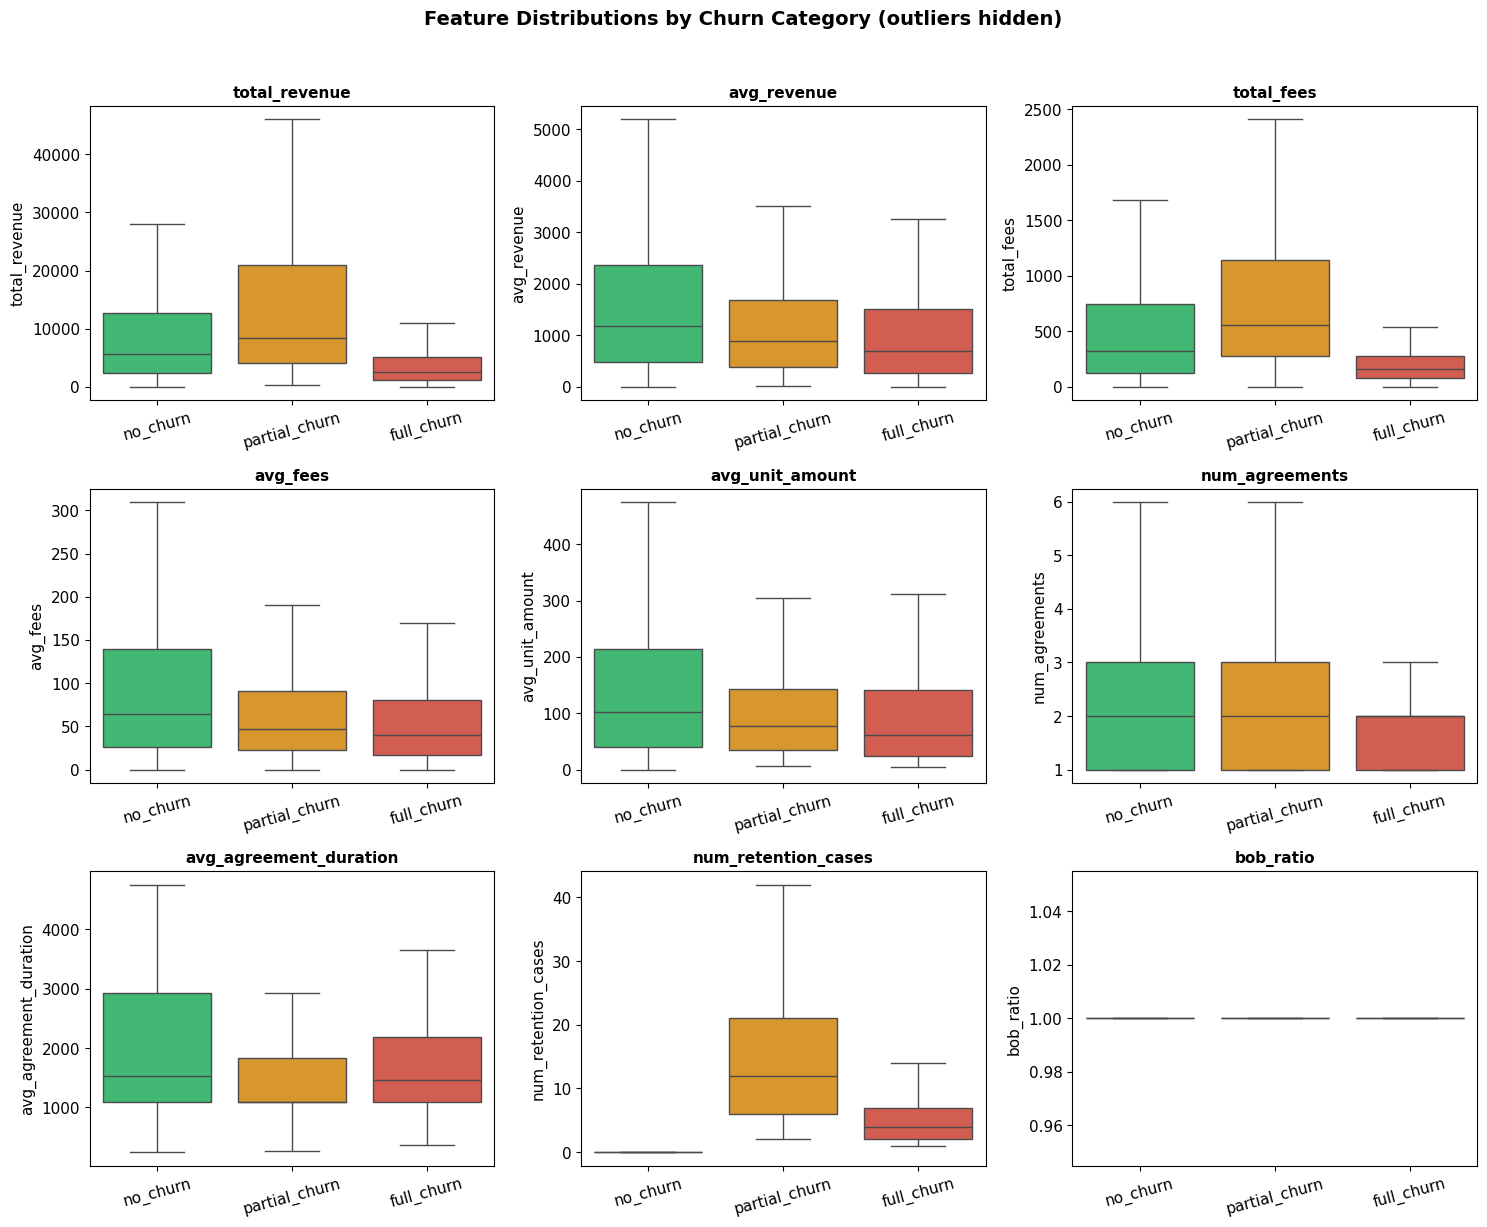

In [11]:
numeric_features = ['total_revenue', 'avg_revenue', 'total_fees', 'avg_fees',
                     'avg_unit_amount', 'num_agreements', 'avg_agreement_duration',
                     'num_retention_cases', 'bob_ratio']
numeric_features = [f for f in numeric_features if f in analysis_df.columns]

n_cols = 3
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

order = ['no_churn', 'partial_churn', 'full_churn']
order = [o for o in order if o in analysis_df['churn_category'].unique()]

for i, feat in enumerate(numeric_features):
    sns.boxplot(data=analysis_df, x='churn_category', y=feat,
                ax=axes[i], palette=['#2ecc71', '#f39c12', '#e74c3c'],
                order=order, showfliers=False)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Churn Category (outliers hidden)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6.2 Correlation Heatmap

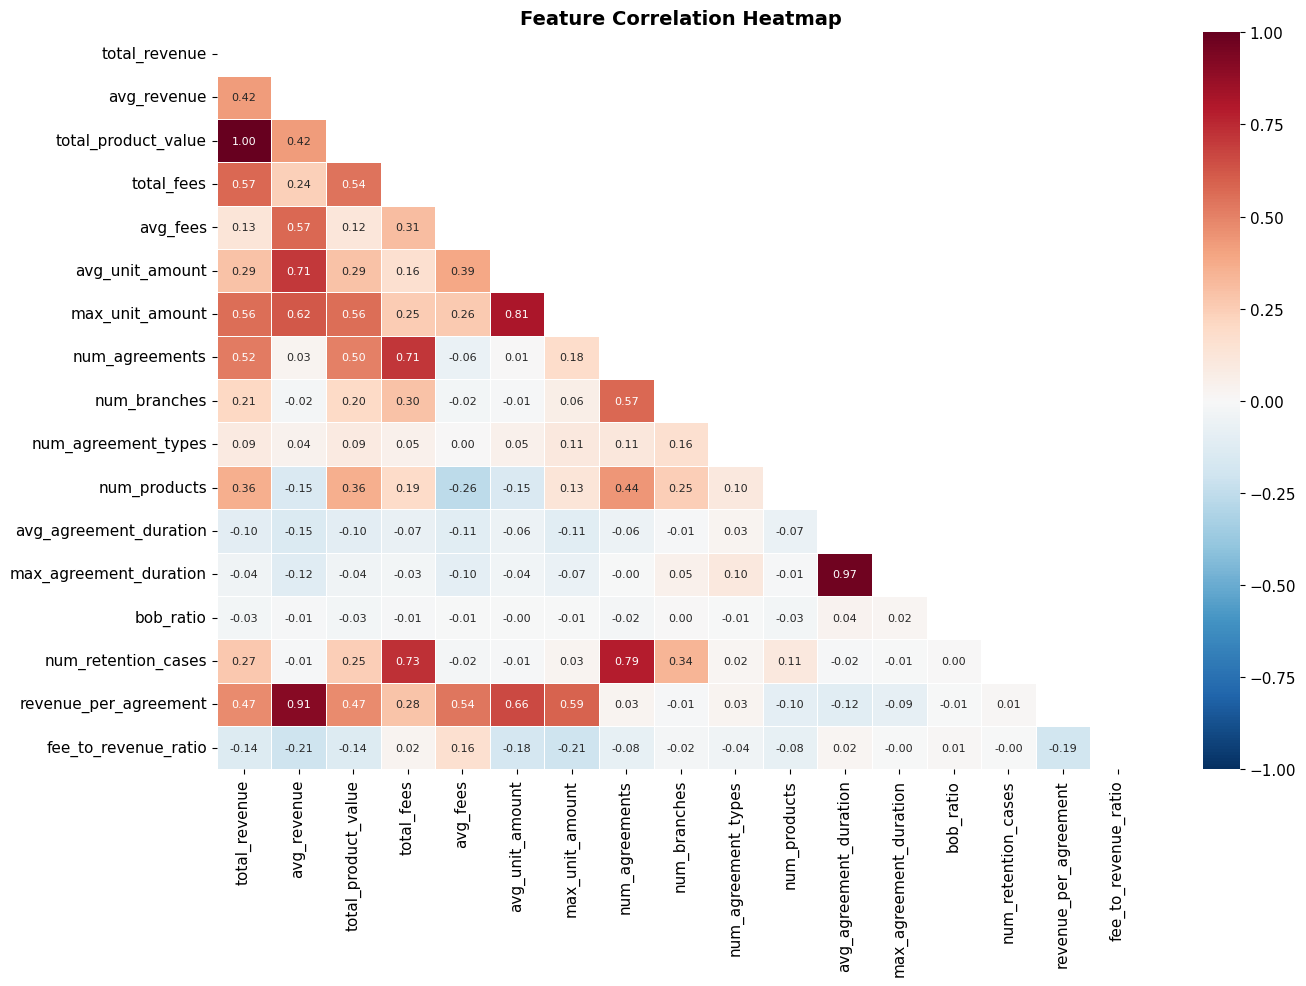


Top 10 Most Correlated Feature Pairs:
total_revenue           total_product_value       0.999369
avg_agreement_duration  max_agreement_duration    0.974729
avg_revenue             revenue_per_agreement     0.906582
avg_unit_amount         max_unit_amount           0.813407
num_agreements          num_retention_cases       0.786674
total_fees              num_retention_cases       0.729588
                        num_agreements            0.712300
avg_revenue             avg_unit_amount           0.708124
avg_unit_amount         revenue_per_agreement     0.662586
avg_revenue             max_unit_amount           0.623314


In [12]:
corr_cols = [c for c in analysis_df.select_dtypes(include=[np.number]).columns
             if c not in ['account_number']]
corr_matrix = analysis_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations
pairs = corr_matrix.unstack().dropna()
pairs = pairs[pairs != 1.0].drop_duplicates()
top_pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(10)
print('\nTop 10 Most Correlated Feature Pairs:')
print(top_pairs.to_string())

## 6.3 Category-wise Mean Comparison

In [13]:
# Group means by churn category
group_summary = analysis_df.groupby('churn_category')[numeric_features].mean()
group_summary = group_summary.reindex(['no_churn', 'partial_churn', 'full_churn'])
display(group_summary.round(2).T)

churn_category,no_churn,partial_churn,full_churn
total_revenue,14116.90,32614.31,7712.01
avg_revenue,1878.70,1321.43,1199.33
total_fees,627.55,1326.72,331.69
avg_fees,104.75,72.88,64.43
avg_unit_amount,174.18,119.30,113.99
num_agreements,2.28,3.59,2.25
avg_agreement_duration,1889.42,1393.98,1649.10
num_retention_cases,1.75,30.13,5.53
bob_ratio,1.00,1.00,1.00


## 6.4 Agreement Type vs Churn

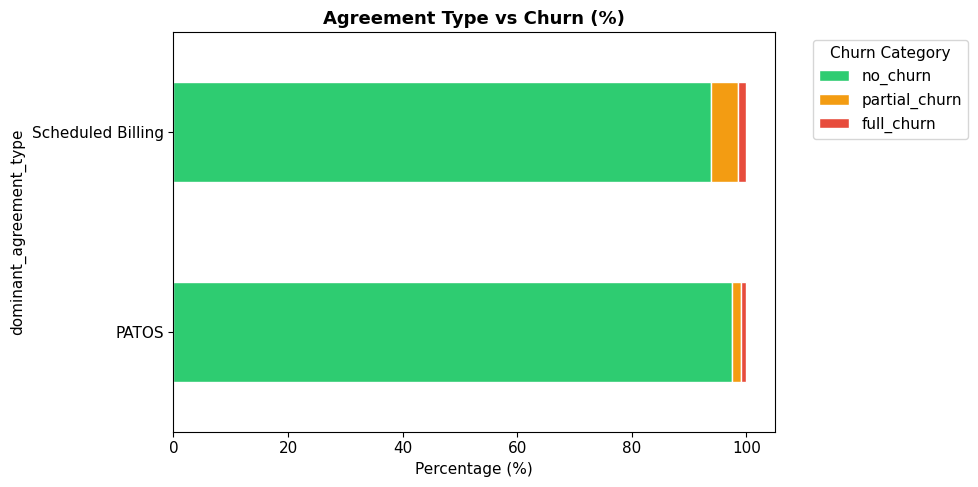

In [14]:
if 'dominant_agreement_type' in analysis_df.columns:
    ct = pd.crosstab(analysis_df['dominant_agreement_type'],
                     analysis_df['churn_category'], normalize='index') * 100
    ct = ct.reindex(columns=['no_churn', 'partial_churn', 'full_churn'], fill_value=0)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ct.plot(kind='barh', stacked=True, ax=ax,
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
    ax.set_title('Agreement Type vs Churn (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.legend(title='Churn Category', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

---
# 7. Hypothesis Testing

We test **6 business-driven hypotheses** using the customer-level data.

| # | Hypothesis | Test |
|---|-----------|------|
| H1 | Agreement type is independent of churn | Chi-Square |
| H2 | Revenue does not differ across churn categories | Kruskal-Wallis |
| H3 | Number of agreements is the same across churn | Kruskal-Wallis |
| H4 | Fee structure is the same across churn | Kruskal-Wallis |
| H5 | Agreement duration has no relationship with churn | Kruskal-Wallis |
| H6 | Financial metrics have no correlation with churn | Spearman |

In [15]:
ht = mods['hypothesis_testing'].HypothesisTesting(analysis_df, target_column='churn_category')

### H1: Agreement Type vs Churn (Chi-Square)

  HYPOTHESIS 1: Agreement Type vs Churn (Chi-Square)
H0: Agreement type is independent of churn category
H1: Agreement type is associated with churn category

  Chi-Square Statistic : 42.5928
  Degrees of Freedom   : 2
  P-Value              : 0.000000
  Decision (α=0.05)    : Reject H0
  → Agreement type IS associated with churn.



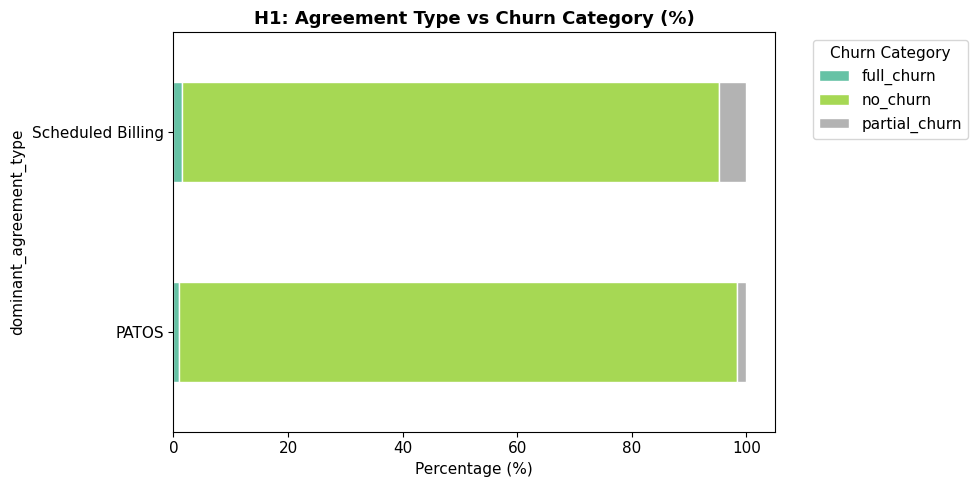

In [16]:
h1_results = ht.hypothesis_1_chi_square()

### H2: Revenue vs Churn (Kruskal-Wallis)

  HYPOTHESIS 2: Revenue vs Churn (Kruskal-Wallis)
H0: Revenue distribution is the same across churn categories
H1: At least one churn category has a different revenue distribution

  Feature             : total_revenue
  H-Statistic         : 289.9306
  P-Value             : 0.000000
  Decision (α=0.05)   : Reject H0
    Mean (     full_churn): 7712.01
    Mean (       no_churn): 14116.90
    Mean (  partial_churn): 32614.31



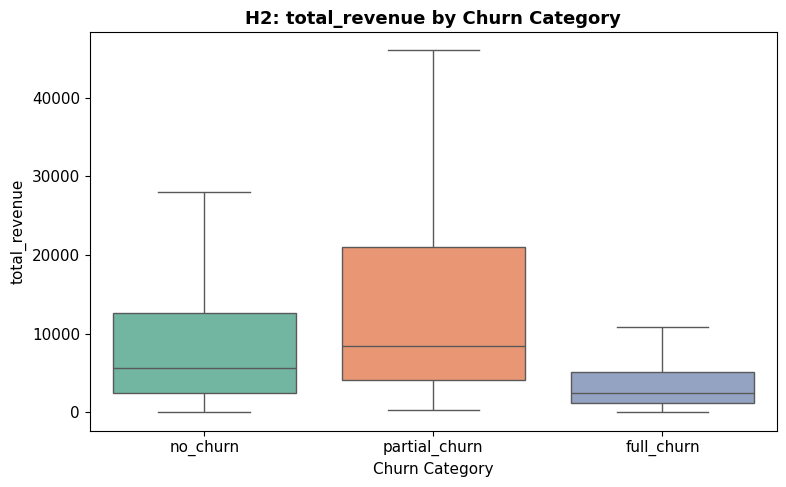

In [17]:
h2_results = ht.hypothesis_2_revenue()

### H3: Number of Agreements vs Churn (Kruskal-Wallis)

  HYPOTHESIS 3: Number of Agreements vs Churn (Kruskal-Wallis)
H0: Number of agreements is the same across churn categories
H1: At least one category has a different number of agreements

  Feature             : num_agreements
  H-Statistic         : 32.9420
  P-Value             : 0.000000
  Decision (α=0.05)   : Reject H0
    Mean (     full_churn): 2.25
    Mean (       no_churn): 2.28
    Mean (  partial_churn): 3.59



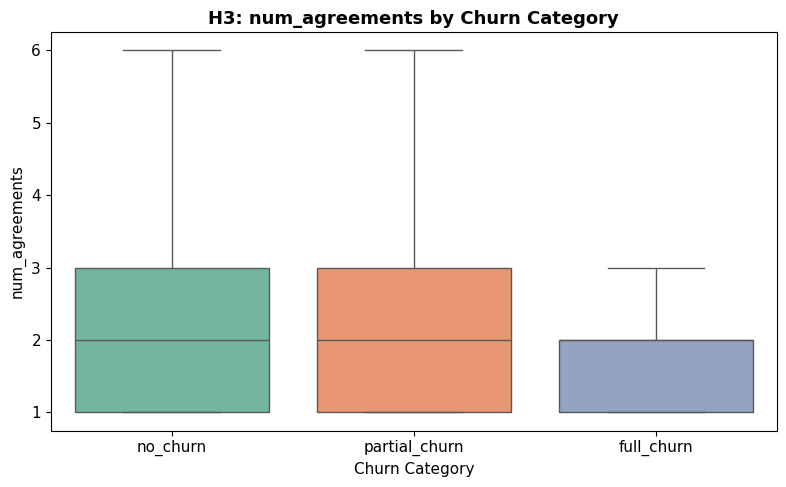

In [18]:
h3_results = ht.hypothesis_3_agreements()

### H4: Fees vs Churn (Kruskal-Wallis)

  HYPOTHESIS 4: Fees vs Churn (Kruskal-Wallis)
H0: Total fees distribution is the same across churn categories
H1: At least one churn category has different fee distribution

  Feature             : total_fees
  H-Statistic         : 298.5059
  P-Value             : 0.000000
  Decision (α=0.05)   : Reject H0
    Mean (     full_churn): 331.69
    Mean (       no_churn): 627.55
    Mean (  partial_churn): 1326.72



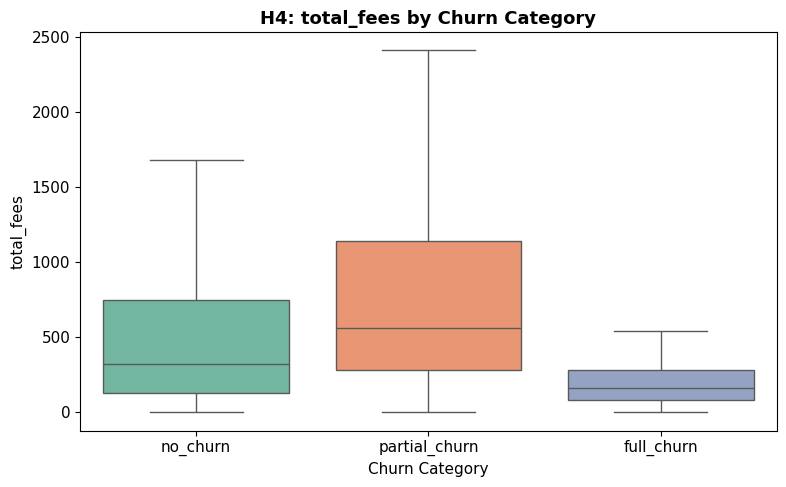

In [19]:
h4_results = ht.hypothesis_4_fees()

### H5: Agreement Duration vs Churn (Kruskal-Wallis)

  HYPOTHESIS 5: Agreement Duration vs Churn (Kruskal-Wallis)
H0: Agreement duration is the same across churn categories
H1: At least one churn category has different agreement duration

  Feature             : avg_agreement_duration
  H-Statistic         : 255.2023
  P-Value             : 0.000000
  Decision (α=0.05)   : Reject H0
    Mean (     full_churn): 1649.10
    Mean (       no_churn): 1889.42
    Mean (  partial_churn): 1393.98



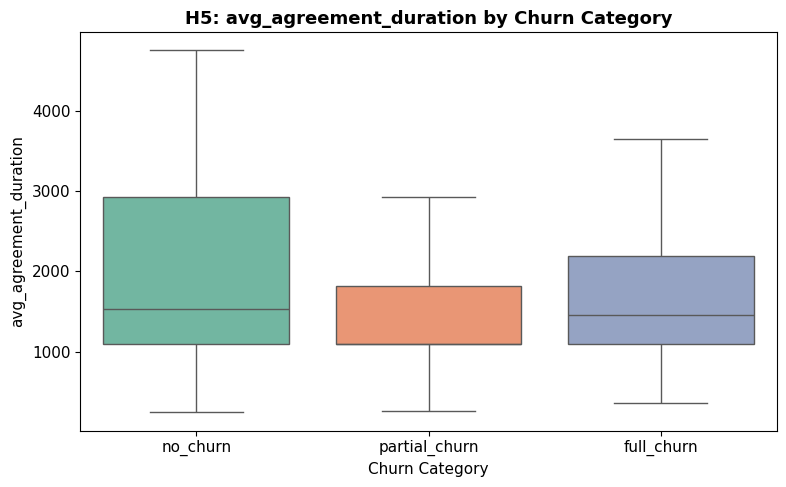

In [20]:
h5_results = ht.hypothesis_5_duration()

### H6: Financial Correlation with Churn (Spearman)

  HYPOTHESIS 6: Financial Correlation with Churn (Spearman)
H0: No monotonic correlation between features and churn severity
H1: Significant correlation exists

              total_revenue:  ρ = +0.0340,  p = 0.000000  → Reject H0
                avg_revenue:  ρ = -0.0673,  p = 0.000000  → Reject H0
                 total_fees:  ρ = +0.0441,  p = 0.000000  → Reject H0
            avg_unit_amount:  ρ = -0.0638,  p = 0.000000  → Reject H0
             num_agreements:  ρ = +0.0322,  p = 0.000001  → Reject H0
     avg_agreement_duration:  ρ = -0.0982,  p = 0.000000  → Reject H0
        num_retention_cases:  ρ = +0.4768,  p = 0.000000  → Reject H0
                  bob_ratio:  ρ = +0.0092,  p = 0.156598  → Fail to Reject H0


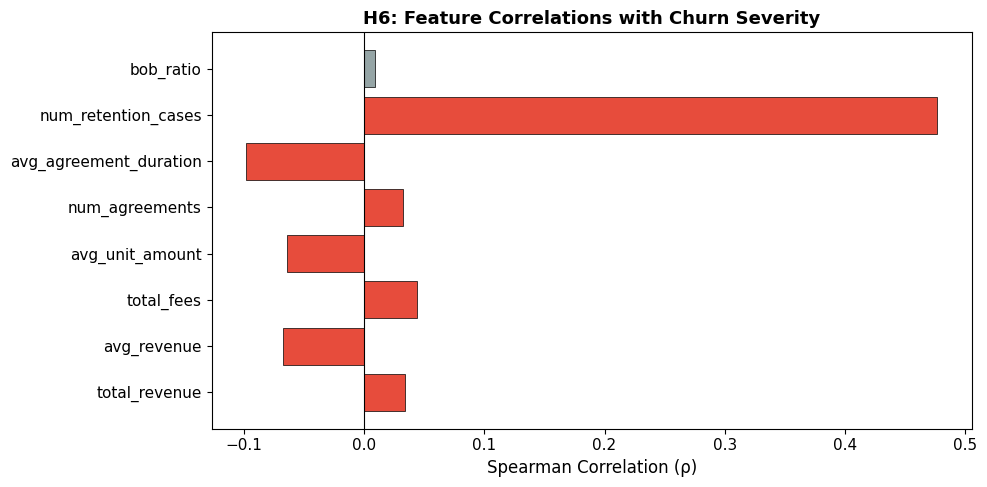

In [21]:
h6_results = ht.hypothesis_6_correlation()

### Hypothesis Testing Summary

In [22]:
# Consolidated summary
all_hyp_results = h1_results + h2_results + h3_results + h4_results + h5_results + h6_results
summary_df = pd.DataFrame(all_hyp_results)
print('\n' + '=' * 65)
print('  HYPOTHESIS TESTING - CONSOLIDATED SUMMARY')
print('=' * 65)
display(summary_df)

# Count decisions
reject_count = (summary_df['Decision'] == 'Reject H0').sum()
total = len(summary_df)
print(f'\n{reject_count} out of {total} tests rejected H0 (significant at α=0.05).')


  HYPOTHESIS TESTING - CONSOLIDATED SUMMARY


,Hypothesis,Feature,Test,Statistic,P-Value,Decision
0,H1,dominant_agreement_type,Chi-Square,42.5928,0.000000,Reject H0
1,H2,total_revenue,Kruskal-Wallis,289.9306,0.000000,Reject H0
2,H3,num_agreements,Kruskal-Wallis,32.9420,0.000000,Reject H0
3,H4,total_fees,Kruskal-Wallis,298.5059,0.000000,Reject H0
4,H5,avg_agreement_duration,Kruskal-Wallis,255.2023,0.000000,Reject H0
5,H6,total_revenue,Spearman,0.0340,0.000000,Reject H0
6,H6,avg_revenue,Spearman,-0.0673,0.000000,Reject H0
7,H6,total_fees,Spearman,0.0441,0.000000,Reject H0
8,H6,avg_unit_amount,Spearman,-0.0638,0.000000,Reject H0
9,H6,num_agreements,Spearman,0.0322,0.000001,Reject H0



12 out of 13 tests rejected H0 (significant at α=0.05).


---
# 8. Key Findings & Next Steps

## Key Findings
1. **Data Merge**: LEFT join from BoB preserves all 23,772 customers (vs 5,628 with inner join)
2. **3-Class Churn**: Proper distribution of no_churn, partial_churn, and full_churn
3. **Feature Engineering**: 15+ customer-level features engineered from BoB data
4. **Hypothesis Testing**: Statistical tests reveal which features significantly differ across churn categories

## Data Ready for Gold Layer
- `data/03_processed/analysis_data.csv`: Customer-level features + churn labels
- `data/03_processed/churn_categorised.csv`: Churn classification output
- `data/03_processed/merged_data.csv`: Row-level merged data